## From-Scratch “MiniTorch” — Notebook Overview

In this notebook we will **implement a minimal deep-learning framework from scratch** (“miniTorch”) and use it to train a simple neural network on the **MNIST** dataset as a toy problem.

### Objectives
- **Layers:** Implement core layers (e.g., `Linear`, `Dropout`, `BatchNorm1D`) with clean APIs.
- **Forward & Backward:** Write explicit **forward** and **backward** passes for every layer (no autograd).
- **Losses:** Implement a **cross-entropy from logits** loss.
- **Training Loop:** Build an epoch-based loop with **train/validation** splits and metrics.
- **Optimization:** Perform **manual SGD** parameter updates (learning rate, gradient averaging, etc.).

### Scope & Assumptions
- We will **not** use PyTorch autograd; gradients are computed **manually**.
- Tensors are used only as numerical containers and for basic ops (matmul, sum, etc.).
- We adopt PyTorch-style `net.train()` / `net.eval()` mode switches for realism.
- The dataset is **MNIST** (28×28 grayscale digits, 10 classes), serving as a **toy setting** to validate our implementation.

### What You’ll Get By the End
- A working “miniTorch” stack: layers → forward/backward → training loop → optimizer.
- Clear, student-friendly code that mirrors real libraries while remaining small and inspectable.



## 1. Loading the MNIST Dataset

We will use the **MNIST** dataset — a classic benchmark of **28×28 grayscale images** of handwritten digits (0–9).  
It contains:
- **60,000** training images
- **10,000** test images

### Steps:
1. **Download & Transform**  
   - Use `torchvision.datasets.MNIST` to automatically download the data.
   - Convert images to tensors and normalize pixel values to the range \([-1, 1]\).

2. **Split into Train & Validation**  
   - The official training set (60,000 samples) will be split into:
     - **Training set:** 80% of the data (48,000 images).
     - **Validation set:** 20% of the data (12,000 images).
   - The split allows us to monitor generalization during training.

3. **Test Set**  
   - The test set (10,000 images) is kept separate and **only used at the end** to report final performance.

### Why Split into Validation?
The validation set helps track **overfitting**:  
- If training accuracy keeps increasing but validation accuracy stalls or decreases, the model is memorizing instead of generalizing.

### Summary
- **Training set:** update model weights.
- **Validation set:** tune hyperparameters & monitor generalization.
- **Test set:** final unbiased evaluation.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.datasets import make_classification
import numpy as np
# pick the seed for reproducibility - change it to explore the effects of random variations
np.random.seed(0)
import random
from tqdm import tqdm
from torch.utils.data import random_split

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

In [3]:
# Define transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load full train dataset
full_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Split into train and validation
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])

# DataLoaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=False)

# Test data
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [4]:
# Example: Iterate over a few batches
for images, labels in trainloader:
    print(images.shape, labels.shape)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])


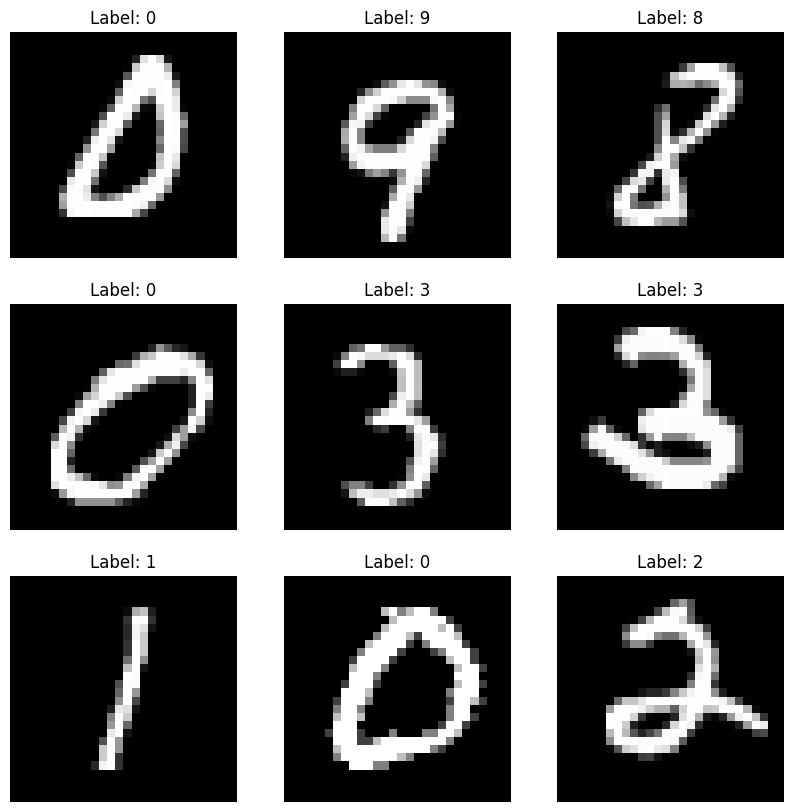

In [5]:
# Check some examples
for images, labels in trainloader:
    # Denormalize the images for plotting
    images = images * 0.5 + 0.5

    # Plot the images
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Plot 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # images[i][0] for grayscale images
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.show()
    break


## 2. Implementing the Linear Layer

The **Linear** (or fully connected / dense) layer is one of the fundamental building blocks of neural networks.  
It performs a **linear transformation** of the input:

$$
Z = XW + b
$$

- **Forward pass:**  
  Takes the input $X \in \mathbb{R}^{\text{batch} \times n_{\text{in}}}$ and computes the weighted sum using the weight matrix $W \in \mathbb{R}^{n_{\text{in}} \times n_{\text{out}}}$ and bias vector $b \in \mathbb{R}^{n_{\text{out}}}$.
- **Backward pass:**  
  Computes the gradients of the loss with respect to $W$, $b$, and $X$ so we can update the parameters during training.
- **Update step:**  
  Applies a gradient descent step to $W$ and $b$ using the computed gradients and a learning rate.

Below is a template where you will fill in the missing pieces (`# TODO`) to implement forward, backward, and update logic.

In [6]:
class Linear:
    """
    A simple fully connected (dense) layer.
    Performs a linear transformation:  Z = XW + b
    """

    def __init__(self, nin, nout, device="cpu"):
        """
        Initialize the layer parameters.
        """
        # Initialize weights from a normal distribution
        self.W = torch.randn(nin, nout, device=device, requires_grad=False)
        # Initialize biases to zero
        self.b = torch.zeros(nout, device=device, requires_grad=False)
        self.training = True  # for compatibility with Dropout/BatchNorm

    def train(self):
        """Switch to training mode."""
        self.training = True
        return self

    def eval(self):
        """Switch to evaluation mode."""
        self.training = False
        return self

    def forward(self, X):
        """
        Forward pass: compute the output of the layer.
        """
        self.X = X  # store for backward pass
        Z = X @ self.W + self.b
        return Z
        pass

    def backward(self, dZ):
        """
        Backward pass: compute gradients w.r.t. W, b, and X.
        """
        #la derivada de la pérdida con respecto a b
        # es la derivada de la pérdda hassta esta capa por la derivada de b (1)
        self.db = dZ.sum(dim=0) 
        self.dW = self.X.t() @ dZ
        self.dX = dZ @ self.W.t()
        return self.dX
        pass

    def update(self, lr):
        """
        Update parameters using gradient descent.
        """
        self.W -= lr * self.dW
        self.b -= lr * self.db
        pass

# Example usage
nin = 4
nout = 3
n_batch = 5
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Simulated input tensor
X = torch.randn(n_batch, nin).to(device)

# Create an instance of the Linear class and compute the linear transformation
net = Linear(nin, nout, device=device)
Z = net.forward(X)
print(Z.shape)

torch.Size([5, 3])


## 3. CrossEntropyFromLogits Loss

To train a neural network for **classification**, we need a loss function that measures how well the predicted class scores (logits) match the true labels.  
A very common choice is the **Cross-Entropy Loss**, combined with the **Softmax** function.

### Step 1: Softmax

Given the logits for each sample:
$$
Z \in \mathbb{R}^{m \times C}
$$
where $m$ is the batch size and $C$ is the number of classes,  
the softmax function converts logits into probabilities:

$$
A_{i,j} = \frac{\exp(Z_{i,j})}{\sum_{k=1}^{C} \exp(Z_{i,k})}
$$

This ensures:
- $A_{i,j} \geq 0$ (all outputs are non-negative)
- $\sum_{j=1}^{C} A_{i,j} = 1$ (rows sum to 1, valid probability distribution).

### Step 2: Cross-Entropy Loss

If $Y_i$ is the true label for sample $i$ (an integer in $[0, C-1]$),  
the cross-entropy loss for one sample is:

$$
\ell_i = -\log\big( A_{i, Y_i} \big)
$$

The loss over the batch is the average:

$$
\mathcal{L} = \frac{1}{m} \sum_{i=1}^m \ell_i
= -\frac{1}{m} \sum_{i=1}^m \log\big( A_{i, Y_i} \big)
$$

### Step 3: Gradient (Backward Pass)

The derivative of the loss with respect to the logits is elegant:

$$
\frac{\partial \mathcal{L}}{\partial Z_{i,j}}
= A_{i,j} - \mathbf{1}[j = Y_i]
$$

That is:
- For the correct class: $A_{i,Y_i} - 1$
- For other classes: $A_{i,j}$

This makes backpropagation very efficient.

---

### Summary

- **Forward pass:** compute softmax + cross-entropy.  
- **Backward pass:** subtract 1 from the probability of the true class.  

This loss is standard for multi-class classification problems such as MNIST.

---

We can express this more compactly in **matrix form**.

Let:
- $ A \in \mathbb{R}^{m \times C} $ be the matrix of softmax outputs,  
- $ Y \in \mathbb{R}^{m \times C} $ be the one-hot encoded true labels,  
- $ m $ = batch size.  

Then the gradient of the loss w.r.t. the logits $Z$ is:

$$
\frac{\partial \mathcal{L}}{\partial Z} = \frac{1}{m}\,(A - Y)
$$

---

### Key Points:
- The subtraction $$ A - Y $$ automatically applies the correct rule to all classes in all samples.
- The factor $ \tfrac{1}{m} $ appears if the loss is averaged across the batch (omit it if summing).
- This compact vectorized form makes backpropagation efficient in practice.

In [7]:
class CrossEntropyFromLogits:
    """
    Implements the combination of:
    - Softmax activation (from raw logits)
    - Cross-entropy loss

    This is a common choice for multi-class classification.
    """

    def forward(self, Z, Y):
        """
        Forward pass: compute the cross-entropy loss from raw logits.

        Args:
            Z (torch.Tensor): Logits (unnormalized scores) of shape (batch_size, n_classes).
            Y (torch.Tensor): True class indices of shape (batch_size,).

        Returns:
            loss torch.Tensor: Scalar value of the cross-entropy loss.
        """
        self.Y = Y  # Store true labels for backward pass

        # TODO: Compute softmax probabilities (convert logits to probabilities)
         # softmax es invariante ante traslaciónes. Evitamos exponenciales 
         # uy grandes para prevenir errores
        Z_stable = Z - Z.max(dim=1, keepdim=True).values
        expZ = torch.exp(Z_stable)
        self.A = expZ / expZ.sum(dim=1, keepdim=True)   

        # TODO: Compute log-softmax (log probabilities)
        # computar el logaritmo de forma directa podría generar valores -inf. Para prevenir
        # errores se desarrolla primero la forma del logaritmo "en el papel" antes de 
        # ponerla aquí
        log_softmax_Z = Z_stable - torch.log(expZ.sum(dim=1, keepdim=True))

        # TODO: Select the log-probabilities of the correct classes for each sample
        #Select the log-probabilities of the correct classes for each sample
        batch_size = Z.shape[0]
        # Usamos torch.arange para crear los índices de las filas [0, 1, 2... batch_size-1]
        # Y tiene los índices de las columnas (las clases correctas)
        log_probs = log_softmax_Z[torch.arange(batch_size), self.Y]
        
        # TODO: Cross-entropy loss: promedio del inverso aditivo de las log-probabilidades
        loss = -log_probs.mean()
        return loss

    def backward(self, n_classes):
        """
        Backward pass: compute the gradient of the loss with respect to logits Z.

        Args:
            n_classes (int): Number of classes in the classification problem.

        Returns:
            torch.Tensor: Gradient dZ of shape (batch_size, n_classes).
        """
        # TODO: One-hot encode the true labels
        m = self.Y.shape[0] #número de etiquetas reales (tamaño del batch)
        Y_one_hot = torch.zeros(m, n_classes, device=self.A.device)  # Matriz m*n_clases
        rows = torch.arange(m, device=self.A.device)  # vector de índices para cada elemento del batch
        Y_one_hot[rows, self.Y] = 1.0 #asignar 1 para la fila del elemento del batch en la casilla 
                                      #de la columna correspondiente al numero de su categoría
        # TODO: Derivative of cross-entropy w.r.t logits: softmax_output - one_hot_labels
        n = self.A.shape[0]
        dZ = (self.A - Y_one_hot) / n
        return dZ


# Example usage
CELoss = CrossEntropyFromLogits()
Y = torch.randint(0, 3, (n_batch,))
loss = CELoss.forward(Z, Y)
print(loss)

tensor(3.3139)


## 4. Training Loop — Forward, Backward, Manual Parameter Updates (No Optimizers Yet)

In this section you’ll complete the **core learning cycle** using only the pieces we’ve built:
1. **Forward pass:** compute logits \(Z\) from inputs \(X\).
2. **Loss:** compute cross-entropy from logits and labels.
3. **Backward (loss):** compute \(dZ = \partial \mathcal{L} / \partial Z\) (vectorized).
4. **Backward (network):** backpropagate \(dZ\) through layers to fill per-parameter grads.
5. **Manual update:** call `net.update(learning_rate)` to apply **plain SGD** updates.

### TODOs (what you must fill in)
- [ ] **Forward:** `Z = net.forward(X)`
- [ ] **Loss:** `loss = CELoss.forward(Z, Y)`
- [ ] **Backward (loss):** `dZ = CELoss.backward(n_classes)`  (matrix form \(A - Y\); include \(1/m\) if you average)
- [ ] **Backward (network):** `net.backward(dZ)`
- [ ] **Update:** `net.update(learning_rate)`  *(manual SGD; no optimizer classes yet)*
- [ ] **Metrics:** accumulate running loss/accuracy for train and val

**Tips**
- Average your **layer gradients** by batch size in each layer (e.g., `dW /= m`) for LR stability.
- Keep **validation/test** forward-only (no `backward`, no `update`).
- If you want to tweak LR per epoch, just modify the variable `learning_rate` before the loop or inside it.

Epoch 1/5 [Val]: 100%|██████████| 188/188 [00:01<00:00, 149.17it/s]


Epoch 1/5 | Train Loss: 3.1022 Acc: 0.7186 | Val Loss: 1.5476 Acc: 0.8140


Epoch 2/5 [Val]: 100%|██████████| 188/188 [00:01<00:00, 170.33it/s]


Epoch 2/5 | Train Loss: 1.3461 Acc: 0.8378 | Val Loss: 1.1901 Acc: 0.8464


Epoch 3/5 [Val]: 100%|██████████| 188/188 [00:01<00:00, 153.72it/s]


...

Epoch 4/5 | Train Loss: 0.9737 Acc: 0.8657 | Val Loss: 0.9193 Acc: 0.8715


Epoch 5/5 [Val]: 100%|██████████| 188/188 [00:01<00:00, 122.48it/s]


Epoch 5/5 | Train Loss: 0.8828 Acc: 0.8717 | Val Loss: 0.8754 Acc: 0.8768


[Test]: 100%|██████████| 157/157 [00:01<00:00, 136.51it/s]


[Test] Loss: 0.8230 | Acc: 0.8812


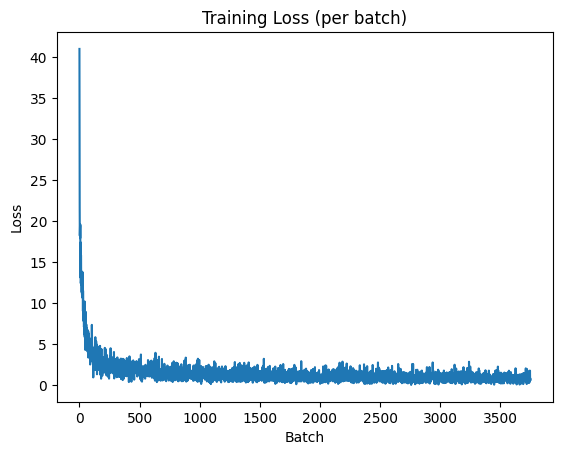

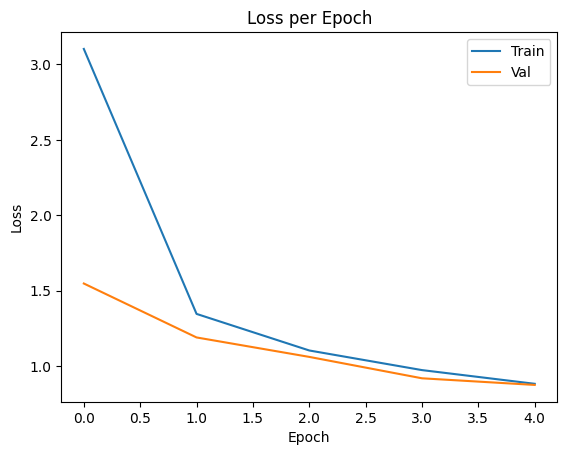

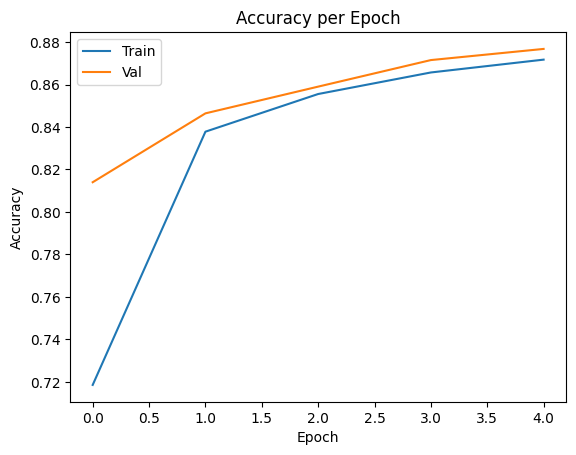

In [8]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
batch_losses = []  # per-batch losses for the plot
num_epochs = 5
learning_rate = 0.1
n_classes = 10
net = Linear(784, n_classes, device=device)
for epoch in range(1, num_epochs + 1):
    # -------- TRAIN --------
    if hasattr(net, "train"): net.train()
    running_loss, tot_correct, tot_samples = 0.0, 0, 0
    total_batches = len(trainloader)

    pbar = tqdm(trainloader, desc=f"Epoch {epoch}/{num_epochs} [Train]")
    for batch_idx, (images, labels) in enumerate(pbar, 1):
        X = images.view(images.size(0), -1).to(device)
        Y = labels.to(device)

        # Forward
        Z = net.forward(X)#TODO
        loss = CELoss.forward(Z, Y)#TODO

        # Backward + update (manual autograd)
        dZ = CELoss.backward(n_classes)
        net.backward(dZ)
        net.update(learning_rate)
        # Stats
        running_loss += loss.detach().cpu().item() #TODO
        batch_losses.append(loss.detach().cpu().item())
        _, predicted = torch.max(Z, 1)
        tot_correct += (predicted == Y).sum().item()
        tot_samples += Y.size(0)

        if batch_idx % max(1, total_batches // 10) == 0:
            pbar.set_postfix(loss=f"{loss.item():.4f}",
                             acc=f"{tot_correct / max(1, tot_samples):.4f}")

    train_loss = running_loss / len(trainloader) #TODO
    train_acc = tot_correct / tot_samples #TODO

    # -------- VALIDATION --------
    if hasattr(net, "eval"): net.eval()
    val_running_loss, val_correct, val_samples = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(valloader, desc=f"Epoch {epoch}/{num_epochs} [Val]"):
            X = images.view(images.size(0), -1).to(device)
            Y = labels.to(device)

            Z = net.forward(X)#TODO
            vloss = CELoss.forward(Z, Y) #TODO
            val_running_loss += vloss.detach().cpu().item()#TODO

            _, predicted = torch.max(Z, 1)
            val_correct += (predicted == Y).sum().item()
            val_samples += Y.size(0)

    val_loss = val_running_loss / len(valloader)
    val_acc = val_correct / val_samples

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# -------- OPTIONAL TEST --------
if 'testloader' in globals() and testloader is not None:
    if hasattr(net, "eval"): net.eval()
    test_correct, test_samples, test_running_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in tqdm(testloader, desc="[Test]"):
            X = images.view(images.size(0), -1).to(device)
            Y = labels.to(device)
            Z = net.forward(X) #TODO
            loss = CELoss.forward(Z, Y)#TODO
            test_running_loss += loss.detach().cpu().item() #TODO
            _, pred = torch.max(Z, 1)
            test_correct += (pred == Y).sum().item()
            test_samples += Y.size(0)
    test_loss = test_running_loss / len(testloader)
    test_acc = test_correct / test_samples
    print(f"[Test] Loss: {test_loss:.4f} | Acc: {test_acc:.4f}")

# -------- PLOTS --------
plt.figure(); plt.plot(np.array(batch_losses))
plt.xlabel('Batch'); plt.ylabel('Loss'); plt.title('Training Loss (per batch)'); plt.show()

plt.figure(); plt.plot(history["train_loss"], label='Train'); plt.plot(history["val_loss"], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss per Epoch'); plt.show()

plt.figure(); plt.plot(history["train_acc"], label='Train'); plt.plot(history["val_acc"], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy per Epoch'); plt.show()

## The `Net` Class: A Simple Sequential Container

To organize our neural network, we define a `Net` class that acts as a **sequential container of layers**.  
This class is inspired by frameworks like PyTorch, but implemented from scratch for educational purposes.

### Key Responsibilities

- **Layer Management:**  
  We can add layers (e.g., `Linear`, `ReLU`, `Dropout`) using `add()`.  
  Each layer must implement:
  - `forward()` — computes the output given inputs.  
  - `backward()` — computes the gradients of the loss w.r.t. its inputs.  
  - `update(lr)` — updates the trainable parameters (if any).  

- **Training/Evaluation Modes:**  
  The class has `train()` and `eval()` methods.  
  These switch the whole network into training or evaluation mode, propagating the setting to layers that support it (like `Dropout`, which behaves differently during training vs evaluation).

- **Forward and Backward Passes:**  
  - `forward(X)` runs the input through all layers in sequence.  
  - `backward(dZ)` propagates gradients in reverse order, from the output back to the input.  

- **Parameter Updates:**  
  `update(lr)` applies gradient descent to all trainable layers, using the provided learning rate.  
  (Later we could replace this with more advanced optimizers like Adam or RMSProp.)

### Next Steps

- **TODOs:**  
  - Implement the details of each layer’s `forward()` and `backward()` functions.  
  - Add parameter updates inside `update()` for layers that have weights.  
  - Complete the training loop that uses this `Net` container to build and train a model on MNIST.  

This design provides a clear and modular structure, making it easy to extend with new layers or optimizers.

In [9]:
class Net:
    """
    A simple sequential container for custom layers.
    Provides PyTorch-like train()/eval() switches and
    runs forward/backward/update across all layers.
    """

    def __init__(self):
        """
        Start with an empty list of layers and set the network
        to training mode by default.
        """
        self.layers = []
        self.training = True  # True = training mode, False = eval mode

    def add(self, layer):
        """
        Add a layer to the network.

        Args:
            layer: Any object that implements forward(), backward(), update(),
                   and (optionally) train()/eval() for mode control.
        """
        self.layers.append(layer)

    # ---- Mode control (pro-style) ----
    def train(self):
        """
        Switch the whole network to training mode and propagate
        the setting to layers that implement train().
        """
        self.training = True
        for layer in self.layers:
            if hasattr(layer, "train"):
                layer.train()
        return self

    def eval(self):
        """
        Switch the whole network to evaluation mode and propagate
        the setting to layers that implement eval().
        """
        self.training = False
        for layer in self.layers:
            if hasattr(layer, "eval"):
                layer.eval()
        return self

    # ---- Core passes ----
    def forward(self, X):
        """
        Forward pass through all layers.

        Args:
            X (torch.Tensor): Input to the network.

        Returns:
            torch.Tensor: Output after the last layer.
        """
        for layer in self.layers:
            #Implement the forward pass
            X = layer.forward(X) #TODO  # output of one layer becomes input to the next
        return X

    def backward(self, dZ):
        """
        Backward pass through all layers in reverse order.

        Args:
            dZ (torch.Tensor): Gradient of the loss w.r.t. network output.

        Returns:
            torch.Tensor: Gradient of the loss w.r.t. the network input.
        """
        for layer in reversed(self.layers):
            #Implement the backward pass
            dZ = layer.backward(dZ)  # each layer returns grad for the previous one
        return dZ

    def update(self, lr):
        """
        Update parameters of all trainable layers with the given learning rate.

        Args:
            lr (float): Learning rate.
        """
        for layer in self.layers:
            # Some layers (e.g., activations) may not have parameters
            if hasattr(layer, "update"):
                layer.update(lr)

### Testing the Implementation

The following cells are intended as a **first test** of the network implementation.  
We build a simple architecture with two linear layers and train it using our custom  
cross-entropy loss. Since we have not yet introduced any **non-linear activation functions**,  
this setup is equivalent to a **softmax regression model** (a linear classifier).  

The purpose here is to verify that the forward pass, backward pass, parameter updates,  
and loss tracking are working correctly before moving on to more complex networks.

In [10]:
# Check if CUDA is available and set the device accordingly
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Forcing the device to CPU (this line will override the previous check)
device = 'cpu'

# Define the number of input features and output classes
n_features = 784
n_classes = 10

# Initialize the network (assuming `Net` is a custom class that you've defined)
net = Net()

# Add a linear layer to the network with 784 input features and 1024 output features
net.add(Linear(n_features, 1024, device=device))

# Add another linear layer with 1024 input features and 10 output features
net.add(Linear(1024, n_classes, device=device))

# Initialize the custom cross-entropy loss function from logits
CEloss = CrossEntropyFromLogits()

Epoch 1/5 [Val]: 100%|██████████| 188/188 [00:01<00:00, 102.25it/s]


Epoch 1/5 | Train Loss: 126.1736 Acc: 0.6561 | Val Loss: 58.1563 Acc: 0.7869


Epoch 2/5 [Val]: 100%|██████████| 188/188 [00:01<00:00, 121.00it/s]


Epoch 2/5 | Train Loss: 50.7512 Acc: 0.8101 | Val Loss: 44.8072 Acc: 0.8305


Epoch 3/5 [Val]: 100%|██████████| 188/188 [00:01<00:00, 104.82it/s]


...

Epoch 4/5 | Train Loss: 35.9792 Acc: 0.8484 | Val Loss: 35.4840 Acc: 0.8504


Epoch 5/5 [Val]: 100%|██████████| 188/188 [00:01<00:00, 123.09it/s]


Epoch 5/5 | Train Loss: 32.4815 Acc: 0.8552 | Val Loss: 33.7545 Acc: 0.8546


[Test]: 100%|██████████| 157/157 [00:01<00:00, 116.32it/s]


[Test] Loss: 30.5167 | Acc: 0.8587


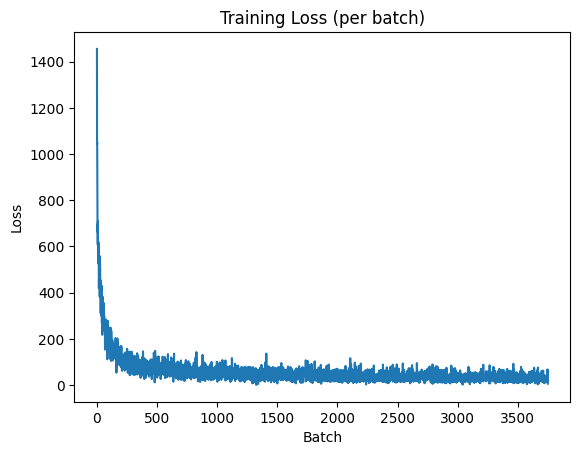

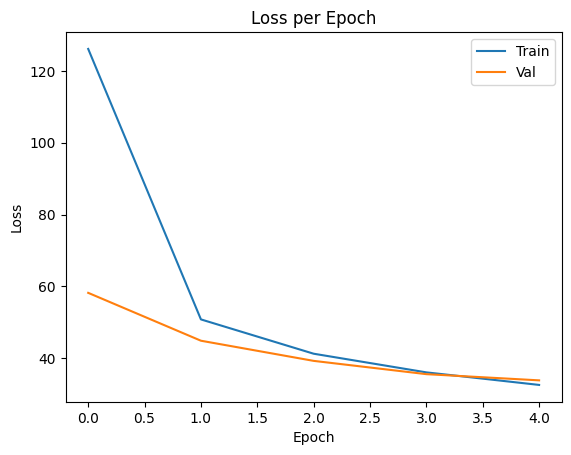

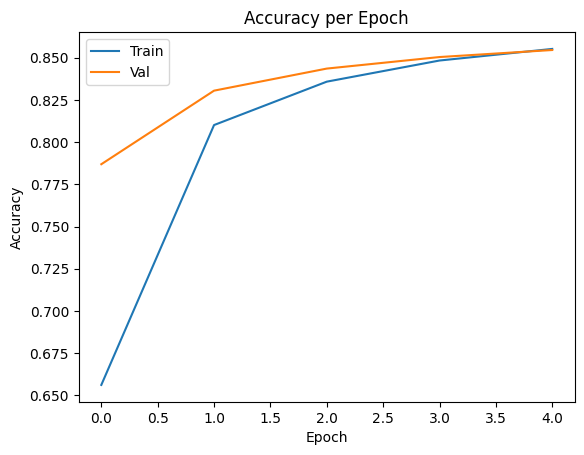

In [11]:
# Set the learning rate
learning_rate = 0.001
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
batch_losses = []  # per-batch losses for the plot

for epoch in range(1, num_epochs + 1):
    # -------- TRAIN --------
    if hasattr(net, "train"): net.train()
    running_loss, tot_correct, tot_samples = 0.0, 0, 0
    total_batches = len(trainloader)

    pbar = tqdm(trainloader, desc=f"Epoch {epoch}/{num_epochs} [Train]")
    for batch_idx, (images, labels) in enumerate(pbar, 1):
        X = images.view(images.size(0), -1).to(device)
        Y = labels.to(device)

        # Forward
        Z = net.forward(X)
        loss = CELoss.forward(Z, Y)

        # Backward + update (manual autograd)
        dZ = CELoss.backward(n_classes)
        _ = net.backward(dZ)
        net.update(learning_rate)

        # Stats
        running_loss += loss.item()
        batch_losses.append(loss.detach().cpu().item())
        _, predicted = torch.max(Z, 1)
        tot_correct += (predicted == Y).sum().item()
        tot_samples += Y.size(0)

        if batch_idx % max(1, total_batches // 10) == 0:
            pbar.set_postfix(loss=f"{loss.item():.4f}",
                             acc=f"{tot_correct / max(1, tot_samples):.4f}")

    train_loss = running_loss / total_batches
    train_acc = tot_correct / tot_samples

    # -------- VALIDATION --------
    if hasattr(net, "eval"): net.eval()
    val_running_loss, val_correct, val_samples = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(valloader, desc=f"Epoch {epoch}/{num_epochs} [Val]"):
            X = images.view(images.size(0), -1).to(device)
            Y = labels.to(device)

            Z = net.forward(X)
            vloss = CELoss.forward(Z, Y)
            val_running_loss += vloss.item()

            _, predicted = torch.max(Z, 1)
            val_correct += (predicted == Y).sum().item()
            val_samples += Y.size(0)

    val_loss = val_running_loss / len(valloader)
    val_acc = val_correct / val_samples

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# -------- OPTIONAL TEST --------
if 'testloader' in globals() and testloader is not None:
    if hasattr(net, "eval"): net.eval()
    test_correct, test_samples, test_running_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in tqdm(testloader, desc="[Test]"):
            X = images.view(images.size(0), -1).to(device)
            Y = labels.to(device)
            Z = net.forward(X)
            loss = CELoss.forward(Z, Y)
            test_running_loss += loss.item()
            _, pred = torch.max(Z, 1)
            test_correct += (pred == Y).sum().item()
            test_samples += Y.size(0)
    test_loss = test_running_loss / len(testloader)
    test_acc = test_correct / test_samples
    print(f"[Test] Loss: {test_loss:.4f} | Acc: {test_acc:.4f}")

# -------- PLOTS --------
plt.figure(); plt.plot(np.array(batch_losses))
plt.xlabel('Batch'); plt.ylabel('Loss'); plt.title('Training Loss (per batch)'); plt.show()

plt.figure(); plt.plot(history["train_loss"], label='Train'); plt.plot(history["val_loss"], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss per Epoch'); plt.show()

plt.figure(); plt.plot(history["train_acc"], label='Train'); plt.plot(history["val_acc"], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy per Epoch'); plt.show()

### ReLU Activation Layer

The **Rectified Linear Unit (ReLU)** is one of the most widely used activation functions in deep learning.  
It introduces **non-linearity** into the network by applying a simple element-wise rule:

$$
a = \text{ReLU}(z) = \max(0, z)
$$

- **Forward Pass**:  
  Each element of the input tensor \( Z \) is mapped to itself if it is positive, or zero if it is negative.  
  This helps prevent the "squashing" effect of sigmoid/tanh and allows gradients to flow more effectively.

- **Backward Pass**:  
  The gradient is passed unchanged for inputs greater than zero and is set to zero for inputs less than or equal to zero:

  $$
  \frac{\partial a}{\partial z} =
  \begin{cases}
  1 & \text{if } z > 0 \\
  0 & \text{if } z \leq 0
  \end{cases}
  $$

- **Update Step**:  
  ReLU has no trainable parameters, so its `update()` method is left empty.

This layer is essential because it allows neural networks to model complex non-linear decision boundaries while remaining computationally efficient.


In [12]:
class ReLU:
    """
    ReLU activation layer.
    """

    def forward(self, Z):
        """
        Perform the forward pass of the ReLU activation function.

        Args:
            Z (torch.Tensor): Input tensor.

        Returns:
            A torch.Tensor: Output tensor with ReLU applied element-wise.
        """
        # torch.maximum evalúa elemento a elemento, por lo que es perfecto para este caso
        self.Z = Z
        self.A = torch.maximum(Z, torch.zeros_like(Z)) #TODO 
        return self.A

    def backward(self, dA):
        """
        Perform the backward pass of the ReLU activation function.

        Args:
            dA (torch.Tensor): Gradient of the loss with respect to the output.

        Returns:
            dZ torch.Tensor: Gradient of the loss with respect to the input.
        """
        #1 cuando z>0 y 0 en otro caso. Podemos aprovecharnos del booleano (self.Z > 0)
        dZ = dA * (self.Z > 0)#TODO
        return dZ

    def update(self,lr):
        """
        ReLU does not have any parameters to update.
        """
        pass


In [13]:
# Check if CUDA is available and set the device accordingly
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Forcing the device to CPU (this line will override the previous check)
device = 'cpu'

# Define the number of input features and output classes
n_features = 784
n_classes = 10

# Initialize the network (assuming `Net` is a custom class that you've defined)
net = Net()

# Add a linear layer to the network with 784 input features and 1024 output features
net.add(Linear(n_features, 1024, device=device))

# Add a non-linear activation function
net.add(ReLU())

# Add another linear layer with 1024 input features and 10 output features
net.add(Linear(1024, n_classes, device=device))

# Initialize the custom cross-entropy loss function from logits
CEloss = CrossEntropyFromLogits()

Epoch 1/5 [Train]:   1%|          | 8/750 [00:00<00:09, 74.37it/s]

Epoch 1/5 [Val]: 100%|██████████| 188/188 [00:01<00:00, 145.05it/s]


Epoch 1/5 | Train Loss: 94.9159 Acc: 0.6254 | Val Loss: 46.0718 Acc: 0.7638


Epoch 2/5 [Val]: 100%|██████████| 188/188 [00:01<00:00, 112.06it/s]


Epoch 2/5 | Train Loss: 37.6795 Acc: 0.7998 | Val Loss: 33.2070 Acc: 0.8132


...

Epoch 4/5 | Train Loss: 25.2090 Acc: 0.8491 | Val Loss: 24.9044 Acc: 0.8522


Epoch 5/5 [Val]: 100%|██████████| 188/188 [00:02<00:00, 86.82it/s]


Epoch 5/5 | Train Loss: 22.3297 Acc: 0.8615 | Val Loss: 23.5163 Acc: 0.8575


[Test]: 100%|██████████| 157/157 [00:01<00:00, 118.12it/s]


[Test] Loss: 21.5975 | Acc: 0.8663


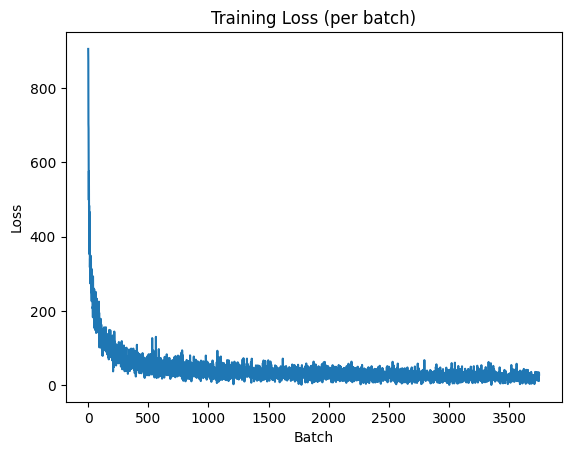

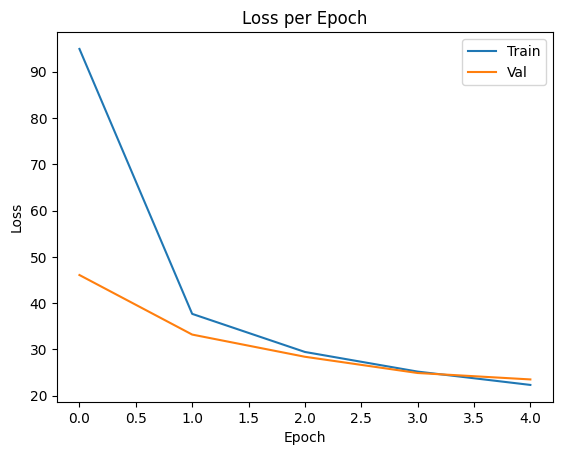

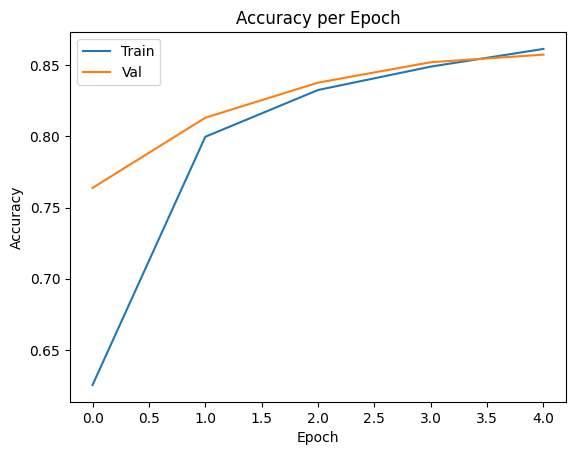

In [14]:
# Set the learning rate
learning_rate = 0.001
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
batch_losses = []  # per-batch losses for the plot

for epoch in range(1, num_epochs + 1):
    # -------- TRAIN --------
    if hasattr(net, "train"): net.train()
    running_loss, tot_correct, tot_samples = 0.0, 0, 0
    total_batches = len(trainloader)

    pbar = tqdm(trainloader, desc=f"Epoch {epoch}/{num_epochs} [Train]")
    for batch_idx, (images, labels) in enumerate(pbar, 1):
        X = images.view(images.size(0), -1).to(device)
        Y = labels.to(device)

        # Forward
        Z = net.forward(X)
        loss = CELoss.forward(Z, Y)

        # Backward + update (manual autograd)
        dZ = CELoss.backward(n_classes)
        _ = net.backward(dZ)
        net.update(learning_rate)

        # Stats
        running_loss += loss.item()
        batch_losses.append(loss.detach().cpu().item())
        _, predicted = torch.max(Z, 1)
        tot_correct += (predicted == Y).sum().item()
        tot_samples += Y.size(0)

        if batch_idx % max(1, total_batches // 10) == 0:
            pbar.set_postfix(loss=f"{loss.item():.4f}",
                             acc=f"{tot_correct / max(1, tot_samples):.4f}")

    train_loss = running_loss / total_batches
    train_acc = tot_correct / tot_samples

    # -------- VALIDATION --------
    if hasattr(net, "eval"): net.eval()
    val_running_loss, val_correct, val_samples = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(valloader, desc=f"Epoch {epoch}/{num_epochs} [Val]"):
            X = images.view(images.size(0), -1).to(device)
            Y = labels.to(device)

            Z = net.forward(X)
            vloss = CELoss.forward(Z, Y)
            val_running_loss += vloss.item()

            _, predicted = torch.max(Z, 1)
            val_correct += (predicted == Y).sum().item()
            val_samples += Y.size(0)

    val_loss = val_running_loss / len(valloader)
    val_acc = val_correct / val_samples

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

# -------- OPTIONAL TEST --------
if 'testloader' in globals() and testloader is not None:
    if hasattr(net, "eval"): net.eval()
    test_correct, test_samples, test_running_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in tqdm(testloader, desc="[Test]"):
            X = images.view(images.size(0), -1).to(device)
            Y = labels.to(device)
            Z = net.forward(X)
            loss = CELoss.forward(Z, Y)
            test_running_loss += loss.item()
            _, pred = torch.max(Z, 1)
            test_correct += (pred == Y).sum().item()
            test_samples += Y.size(0)
    test_loss = test_running_loss / len(testloader)
    test_acc = test_correct / test_samples
    print(f"[Test] Loss: {test_loss:.4f} | Acc: {test_acc:.4f}")

# -------- PLOTS --------
plt.figure(); plt.plot(np.array(batch_losses))
plt.xlabel('Batch'); plt.ylabel('Loss'); plt.title('Training Loss (per batch)'); plt.show()

plt.figure(); plt.plot(history["train_loss"], label='Train'); plt.plot(history["val_loss"], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss per Epoch'); plt.show()

plt.figure(); plt.plot(history["train_acc"], label='Train'); plt.plot(history["val_acc"], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy per Epoch'); plt.show()

### Extending the Neural Network

At this point, we have implemented the essential components of a neural network:  
- **Linear transformations (fully connected layers)** to project data into new spaces,  
- **Non-linear activation functions** such as ReLU to introduce complexity and allow the network to model non-linear relationships, and  
- **A cost function (e.g., Cross-Entropy)** to measure the discrepancy between predictions and true labels.  

While this setup already allows us to train a functional neural network, more advanced operations can significantly improve performance and generalization. Two of the most important techniques are:  

- **Dropout**: Randomly disables a fraction of neurons during training, preventing co-adaptation and reducing overfitting.  
- **Batch Normalization**: Normalizes intermediate activations across a mini-batch, stabilizing training and often accelerating convergence.  

Adding these operations will bring our implementation closer to modern deep learning practices, making the models both more robust and efficient.


### Batch Normalization

Batch Normalization (BN) is used to stabilize and accelerate training by normalizing activations.  
Given input activations $X \in \mathbb{R}^{m \times d}$ (batch size $m$, features $d$):

---

**Training mode**

Batch statistics:  
$$
\mu_{\mathrm{B}}=\frac{1}{m}\sum_{i=1}^m X_i
$$  
$$
\sigma^2_{\mathrm{B}}=\frac{1}{m}\sum_{i=1}^m \left(X_i-\mu_{\mathrm{B}}\right)^2
$$

Normalize, then scale/shift:  
$$
\hat{X}_i=\frac{X_i-\mu_{\mathrm{B}}}{\sqrt{\sigma^2_{\mathrm{B}}+\varepsilon}}
$$  
$$
Y_i=\gamma\,\hat{X}_i+\beta
$$

Update running (EMA) statistics with momentum $\alpha$:  
$$
\mu_{\mathrm{R}} \leftarrow (1-\alpha)\,\mu_{\mathrm{R}} + \alpha\,\mu_{\mathrm{B}}
$$  
$$
\sigma^2_{\mathrm{R}} \leftarrow (1-\alpha)\,\sigma^2_{\mathrm{R}} + \alpha\,\sigma^2_{\mathrm{B}}
$$

---

**Inference mode**

Use stored running statistics (no updates):  
$$
\hat{X}_i=\frac{X_i-\mu_{\mathrm{R}}}{\sqrt{\sigma^2_{\mathrm{R}}+\varepsilon}}
$$  
$$
Y_i=\gamma\,\hat{X}_i+\beta
$$

---

**Summary:**  
- **Training:** use $(\mu_{\mathrm{B}}, \sigma^2_{\mathrm{B}})$, normalize, scale/shift, update $(\mu_{\mathrm{R}}, \sigma^2_{\mathrm{R}})$.  
- **Inference:** use $(\mu_{\mathrm{R}}, \sigma^2_{\mathrm{R}})$ collected during training, normalize, scale/shift, **no updates**.

---

### Task

Implement **BatchNorm as a class** with the following:

- **Forward pass (`forward`)**  
  - #TODO compute batch mean $\mu_{\mathrm{B}}$ and variance $\sigma^2_{\mathrm{B}}$ (training)  
  - #TODO normalize input $X$  
  - #TODO scale and shift using $\gamma, \beta$  
  - #TODO update running mean/variance (training only)  
  - #TODO use running statistics in inference mode  

- **Backward pass (`backward`)**  
  - #TODO compute gradient of loss w.r.t. $\hat{X}$  
  - #TODO propagate through normalization to get $dX$  
  - #TODO compute gradients w.r.t. parameters $\gamma, \beta$  

- **Update parameters (`update`)**  
  - #TODO update $\gamma, \beta$ using the learning rate


In [15]:
class BatchNorm1D:
    """
    Batch Normalization for 2D inputs: (batch, features).

    TRAIN: compute batch stats, normalize, update running stats, support backward().
    EVAL:  use running stats, no updates, typically no backward().
    """

    def __init__(self, n_features, eps=1e-5, momentum=0.1, device="cpu"):
        self.eps = eps
        self.momentum = momentum
        self.device = device

        # Learnable affine parameters
        self.gamma = torch.ones(n_features, device=device, requires_grad=False)
        self.beta  = torch.zeros(n_features, device=device, requires_grad=False)

        # Running (inference) statistics
        self.running_mean = torch.zeros(n_features, device=device, requires_grad=False)
        self.running_var  = torch.ones(n_features,  device=device, requires_grad=False)

        # Mode flag
        self.training = True

        # Caches for backward
        self.X = None
        self.X_hat = None
        self.batch_mean = None
        self.batch_var = None
        self.std = None

        # Grads for parameters
        self.dgamma = None
        self.dbeta  = None

    def train(self): self.training = True;  return self
    def eval(self):  self.training = False; return self

    def forward(self, X):
        """
        Args:
            X: (batch, features)
        Returns:
            Y: (batch, features)
        """
        if self.training:
            # ===== TODO: compute batch statistics along batch dim =====
            self.batch_mean = torch.sum(X, dim=0)/X.shape[0]      # batch size

            self.batch_var  = self.batch_var = torch.sum((X - self.batch_mean)**2, dim=0) / X.shape[0]  # use unbiased=False
            # ===== TODO: compute std and normalized activations =====
            self.std   = self.std = torch.sqrt(self.batch_var + 1e-5)
            self.X_hat = (X - self.batch_mean) / self.std
            #
            # ===== TODO: update running stats (EMA) =====
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * self.batch_mean
            self.running_var  = (1 - self.momentum) * self.running_var  + self.momentum * self.batch_var
            pass
        else:
            # ===== TODO: inference normalization using running stats =====
            self.std   = torch.sqrt(self.running_var + self.eps)
            self.X_hat = (X - self.running_mean) / self.std
            pass

        # Cache input for backward
        self.X = X

        # ===== TODO: affine transform Y = gamma * X_hat + beta =====
        Y = self.gamma * self.X_hat + self.beta
        return Y
        pass

    def backward(self, dY):
        """
        Args:
            dY: upstream gradient (batch, features)
        Returns:
            dX: gradient wrt input X (batch, features)
        """
        if not self.training:
            # In this teaching framework we forbid backward in eval to emphasize the distinction.
            raise RuntimeError("Backward called in eval() mode. Use training mode for gradient computation.")

        m = dY.size(0)  # batch size

        # ===== TODO: parameter gradients =====
        self.dbeta = dY.sum(dim=0)
        self.dgamma = (dY * self.X_hat).sum(dim=0)
        
        # ===== TODO: gradient wrt normalized activations =====
        dx_hat = dY * self.gamma

        # The following hints reflect the standard BN backward derivation:
        x_mu   = self.X - self.batch_mean
        invstd = 1.0 / self.std

 
        # ===== TODO: compute dvar and dmean using cached tensors =====
        #simplemente utilizamos d_hat (derivada de la perdida con respecto a x_hat)
        # por regla de la cadena y luego derivamos x_hat con respecto a la VARIANZA
        dvar  = torch.sum(dx_hat * x_mu * -0.5 * (invstd ** 3), dim=0)
        #ya que la media es parte de la fórmula de x_hat y de la varianza hay que incluir ambas derivadas
        dmean = torch.sum(-dx_hat * invstd, dim=0) + dvar * torch.mean(-2.0 * x_mu, dim=0)
        #
        # ===== TODO: put it all together to get dX =====
        dX = dx_hat * invstd + (2.0 / m) * x_mu * dvar + dmean / m
        
        return dX
        pass

    def update(self, lr):
        """
        Simple SGD update for gamma and beta.
        """
        # ===== TODO: apply SGD step to gamma and beta =====
        self.gamma -= lr * self.dgamma
        self.beta  -= lr * self.dbeta
        pass


### Inverted Dropout ###

Let:  
$ p = \text{drop probability (fraction of units set to zero in training)}$
$ q = 1-p = \text{keep probability} $
$ X \in \mathbb{R}^{m \times d} = \text{activations (batch } m, \text{ features } d) $
$ M \in \left\{ 0, \frac{1}{q} \right\}^{m \times d} = \text{dropout mask} $

---

**Training mode:**

We sample the mask $$ M $$ as:
$$
M_{ij} =
\begin{cases}
\frac{1}{q}, & \text{with probability } q, \\
0, & \text{with probability } p
\end{cases}
$$

Then the output is:
$$
Y = X \odot M
$$

**Expected value during training:**
$$
\mathbb{E}[Y] = \mathbb{E}[X \odot M] = X \cdot \mathbb{E}[M] = X \cdot \left(q \cdot \frac{1}{q} + p \cdot 0\right) = X
$$

Thus, the expected activations in training match those in inference.

---

**Inference mode:**

No dropout, no scaling:
$$
Y = X
$$

Since training already scaled the kept units by $$ \tfrac{1}{q} $$, the magnitude matches without extra work.

---

**Why not multiply by $ p $?**

Multiplying by $ p $ would shrink the kept activations instead of preserving their expected value:
$$
\mathbb{E}[Y] = X \cdot p \quad \neq \quad X
$$

That would require extra scaling at inference, which *inverted dropout* avoids.

---

**Summary:**

**Training:**  
$$
Y = X \odot M, \quad M_{ij} \in \left\{0, \tfrac{1}{1-p}\right\}
$$

**Inference:**  
$$
Y = X
$$

Property preserved:  
$$
\mathbb{E}[Y] = X
$$

---

### ✅ Task

- Implement an **`Inverted Dropout`** layer with the following methods:  
  - `forward(X)`:  
    - In **training mode**, apply mask $$ M $$ as above.  
    - In **evaluation mode**, return $$ X $$.  
  - `backward(dY)`: propagate gradients through the same mask.  
  - `train()` / `eval()`: toggle between training and inference modes.  
  - `update(lr)`: no parameters to update, but include for API consistency.  

- Verify by simulation that:  
  1. The expected output of the dropout layer in **training** matches the original input.  
  2. No scaling is needed in **evaluation**.


In [16]:
import torch

class Dropout:
    """
    Inverted Dropout (for fully-connected tensors [batch, features]).

    - TRAIN: randomly zeroes activations with prob p, and rescales by 1/(1-p)
             so the expected activation stays constant.
    - EVAL:  identity (no dropout, no scaling).

    Students must implement the forward and backward passes.
    """

    def __init__(self, p=0.5, device="cpu"):
        """
        Args:
            p (float): Drop probability in [0,1). Typical values: 0.1~0.5
            device (str): 'cpu' or 'cuda'
        """
        assert 0.0 <= p < 1.0, "p must be in [0, 1)."
        self.p = p
        self.device = device
        self.training = True
        self.mask = None  # cache for backward

    # Mode control
    def train(self):
        self.training = True
        return self

    def eval(self):
        self.training = False
        return self

    def forward(self, X):
        """
        Forward pass of dropout.

        Args:
            X: Tensor of shape (batch, features)
        Returns:
            Tensor of same shape
        """
        if self.training and self.p > 0.0:
            # TODO: Implement inverted dropout
            keep_prob = 1 - self.p
            # 2. Sample a Bernoulli mask with probability keep_prob
            self.mask = (torch.rand_like(X) < keep_prob).float()
            # 3. Scale the mask by 1 / keep_prob
            self.mask = self.mask / keep_prob
            # 4. Multiply X by the mask and return
            return X * self.mask
            pass
        else:
            # TODO: In eval mode, dropout is a no-op
            #modificamos la máscara por 1s para prevenir errores
            self.mask = torch.ones_like(X)
            return X
            pass

    def backward(self, dY):
        """
        Backward pass of dropout.

        Args:
            dY: Gradient wrt output, shape (batch, features)
        Returns:
            dX: Gradient wrt input, shape (batch, features)
        """
        # TODO: Backprop through dropout
        #la derivada de esta capa es simplemente la máscara
        if self.training and self.p > 0.0:
            return dY * self.mask
        else:
            return dY
        pass

    def update(self, lr):
        """
        No learnable parameters in Dropout, so nothing to update.
        Kept for API consistency.
        """
        pass



## Final Task — Put It All Together

In this capstone exercise you will **assemble a complete mini deep-learning stack** and use it to train MNIST models. You’ll integrate **Linear**, **ReLU**, **BatchNorm1D**, and **Dropout**, write a clean **training/validation loop**, experiment with **different architectures**, and finally **package your code** into a reusable Python module.

### What to Build

1. **Model Architectures (experiment)**
   - Start with a baseline: `Linear(784→10)` (softmax regression).
   - Add depth + non-linearities:
     - Example A: `Linear(784→256) → ReLU → Linear(256→10)`
     - Example B: `Linear(784→256) → BatchNorm1D → ReLU → Dropout(p=0.2) → Linear(256→10)`
     - Example C (deeper): `784→512→BatchNorm→ReLU→Dropout→256→BatchNorm→ReLU→Dropout→10`
   - Try **2–3 architectures**. Log train/val loss & accuracy per epoch.

2. **Training Loop (manual updates, no optimizers yet)**
   - Forward → Loss (CrossEntropyFromLogits) → Backward (matrix form) → `net.backward(dZ)` → `net.update(lr)`.
   - Validation after each epoch (no grads, no updates).
   - Record to `history = {"train_loss","train_acc","val_loss","val_acc"}`.
   - Plots: per-batch loss; per-epoch loss/accuracy (train vs. val).

3. **Regularization & Stabilization**
   - **Dropout:** compare `p ∈ {0.0, 0.2, 0.5}`.
   - **BatchNorm:** place BN **before** ReLU in FC blocks (common practice).
   - Optional extras (if time): weight decay (L2), gradient clipping, LR schedule.

4. **Packaging Your Framework**
   - Create a single file **`minitorch.py`** with all components:
     - Layers: `Linear`, `ReLU`, `BatchNorm1D`, `Dropout`
     - Loss: `CrossEntropyFromLogits`
     - Container: `Net`
     - (Optional) utility functions (e.g., accuracy)
   - Import it from your notebook and train.

---

### Deliverables

- **Notebook results:**
  - Table or brief summary of architectures tried, best val accuracy, and comments.
  - Training curves (loss & accuracy) showing the effect of BN/Dropout.
- **`minitorch.py`** file with clean docstrings and minimal dependencies.

---

### Suggested Evaluation Protocol

- Use the same **train/val split** across runs (fix a seed).
- Train for **~5–10 epochs** (enough to see trends).
- Report **best validation accuracy** and final **test accuracy** for your top model.
- Briefly explain **what helped** (BN, Dropout, depth) and **why**.

---

### Checklist / TODOs

- [ ] Implement **forward** and **backward** in `Linear`, `ReLU`, `BatchNorm1D`, `Dropout`.
- [ ] Implement **CrossEntropyFromLogits** with vectorized gradient \(dZ = A - Y\).
- [ ] Write training loop with **manual parameter updates** (`net.update(lr)`).
- [ ] Add **BatchNorm** and **Dropout** in your architectures and compare.
- [ ] Track and plot **history** for train/val.
- [ ] Save best model metrics and briefly **analyze results**.
- [ ] Package everything into **`minitorch.py`** and re-run using imports.

---

### Example `minitorch.py` Skeleton (fill in your implementations)

```python
# minitorch.py
import torch

class Net:
    def __init__(self): self.layers=[]; self.training=True
    def add(self, layer): self.layers.append(layer)
    def train(self): self.training=True; [getattr(l,'train',lambda:None)() for l in self.layers]; return self
    def eval(self):  self.training=False;[getattr(l,'eval', lambda:None)() for l in self.layers]; return self
    def forward(self, X):
        for layer in self.layers: X = layer.forward(X)
        return X
    def backward(self, dZ):
        for layer in reversed(self.layers): dZ = layer.backward(dZ)
        return dZ
    def update(self, lr):
        for layer in self.layers:
            if hasattr(layer, "update"): layer.update(lr)

class Linear:
    # TODO: init (W,b), forward, backward (avg grads), update, parameters (optional)
    ...

class ReLU:
    # TODO: forward (max(0,z)), backward (mask), update (pass)
    ...

class BatchNorm1D:
    # TODO: forward (train/infer paths, EMA), backward (γ, β, dX), update
    ...

class Dropout:
    # TODO: forward (inverted dropout), backward (mask), update (pass)
    ...

class CrossEntropyFromLogits:
    # TODO: forward (softmax/log-softmax + NLL), backward (A - one_hot(Y))
    ...


In [17]:
from minitorchFelipe import train_model, plot_per_batch_loss, plot_history
import torch
import matplotlib.pyplot as plt
import pandas as pd

def set_seed(seed=123):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(123)
device

'cpu'

In [18]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import random_split, DataLoader

# Seed para que el split sea SIEMPRE el mismo
seed = 123
g = torch.Generator().manual_seed(seed)

# Define transform (opción 1: tu normalización)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
full_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size], generator=g)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
valloader   = DataLoader(valset,   batch_size=64, shuffle=False)

testset   = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

In [19]:
# =========================
# Model builder (MNIST)
# =========================
def build_mnist_net(arch: str, device: str = "cpu", p_drop: float = 0.5) -> Net:
    """
    Required MNIST architectures.

    arch:
      - "baseline": Linear(784->10)
      - "A":        Linear(784->256) -> ReLU -> Linear(256->10)
      - "B":        Linear(784->256) -> BatchNorm1D -> ReLU -> Dropout(p) -> Linear(256->10)
      - "C":        784->512->BN->ReLU->Drop->256->BN->ReLU->Drop->10
    """
    net = Net()

    if arch == "baseline":
        net.add(Linear(784, 10, device=device))

    elif arch == "A":
        net.add(Linear(784, 256, device=device))
        net.add(ReLU())
        net.add(Linear(256, 10, device=device))

    elif arch == "B":
        net.add(Linear(784, 256, device=device))
        net.add(BatchNorm1D(256, device=device))
        net.add(ReLU())
        net.add(Dropout(p=p_drop, device=device))
        net.add(Linear(256, 10, device=device))

    elif arch == "C":
        net.add(Linear(784, 512, device=device))
        net.add(BatchNorm1D(512, device=device))
        net.add(ReLU())
        net.add(Dropout(p=p_drop, device=device))

        net.add(Linear(512, 256, device=device))
        net.add(BatchNorm1D(256, device=device))
        net.add(ReLU())
        net.add(Dropout(p=p_drop, device=device))

        net.add(Linear(256, 10, device=device))

    else:
        raise ValueError(f"Unknown architecture: {arch}")

    return net

# =========================
# Leaky-RELU to prevent neuronal death
# =========================

class LeakyReLU:
    """Leaky ReLU activation."""

    def __init__(self, alpha: float = 0.01):
        self.alpha = alpha
        self.Z: Optional[torch.Tensor] = None

    def forward(self, Z: torch.Tensor) -> torch.Tensor:
        self.Z = Z
        return torch.maximum(Z, self.alpha * Z)

    def backward(self, dA: torch.Tensor) -> torch.Tensor:
        dZ = torch.where(self.Z > 0, 1.0, self.alpha)
        return dA * dZ

    def update(self, lr: float):
        # no params
        pass

# =========================
# Optimizer + schedules (NEW)
# =========================
class SGDMomentum:
    """
    Minimal SGD with momentum + L2 (weight decay).

    Notes:
      - weight_decay is applied ONLY to Linear.W (common practice).
      - no weight decay on Linear.b.
      - This version is intentionally minimal and matches your class.
    """

    def __init__(self, lr=0.1, momentum=0.9, weight_decay=1e-4):
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        self.v = {}  # key -> velocity tensor

    def _vel(self, key, param):
        if key not in self.v:
            self.v[key] = torch.zeros_like(param)
        return self.v[key]

    def step(self, net: Net):
        for layer in net.layers:
            if isinstance(layer, Linear):

                # ---- W (with L2) ----
                if layer.dW is not None:
                    gW = layer.dW + self.weight_decay * layer.W
                    vW = self._vel((id(layer), "W"), layer.W)
                    vW.mul_(self.momentum).add_(gW)
                    layer.W.add_(-self.lr * vW)

                # ---- b (no L2) ----
                if layer.db is not None:
                    gb = layer.db
                    vb = self._vel((id(layer), "b"), layer.b)
                    vb.mul_(self.momentum).add_(gb)
                    layer.b.add_(-self.lr * vb)


def step_lr(ep: int, base_lr: float, step_size: int = 40, gamma: float = 0.1) -> float:
    """
    Step decay schedule.

    Every 'step_size' epochs:
      lr = lr * gamma

    Example: base_lr=0.1, step_size=40, gamma=0.1
      ep 1-40   -> 0.1
      ep 41-80  -> 0.01
      ep 81-120 -> 0.001
    """
    k = (ep - 1) // step_size
    return base_lr * (gamma ** k)

device: cpu
Epoch 01 | train loss 12.9584 acc 0.2694 | val loss 6.0826 acc 0.4743
Epoch 02 | train loss 4.5824 acc 0.5700 | val loss 3.5671 acc 0.6398
Epoch 03 | train loss 3.0789 acc 0.6762 | val loss 2.7311 acc 0.7101
Epoch 04 | train loss 2.4737 acc 0.7289 | val loss 2.3267 acc 0.7448
Epoch 05 | train loss 2.1508 acc 0.7592 | val loss 2.0759 acc 0.7658
Epoch 06 | train loss 1.9447 acc 0.7788 | val loss 1.9046 acc 0.7827
Epoch 07 | train loss 1.8015 acc 0.7925 | val loss 1.7818 acc 0.7922
Epoch 08 | train loss 1.6911 acc 0.8041 | val loss 1.6898 acc 0.7990
Epoch 09 | train loss 1.6060 acc 0.8131 | val loss 1.6064 acc 0.8072
Epoch 10 | train loss 1.5347 acc 0.8193 | val loss 1.5402 acc 0.8129
Epoch 11 | train loss 1.4721 acc 0.8240 | val loss 1.4876 acc 0.8184
Epoch 12 | train loss 1.4211 acc 0.8288 | val loss 1.4340 acc 0.8246
Epoch 13 | train loss 1.3740 acc 0.8330 | val loss 1.3858 acc 0.8294
Epoch 14 | train loss 1.3335 acc 0.8366 | val loss 1.3519 acc 0.8310
Epoch 15 | train loss

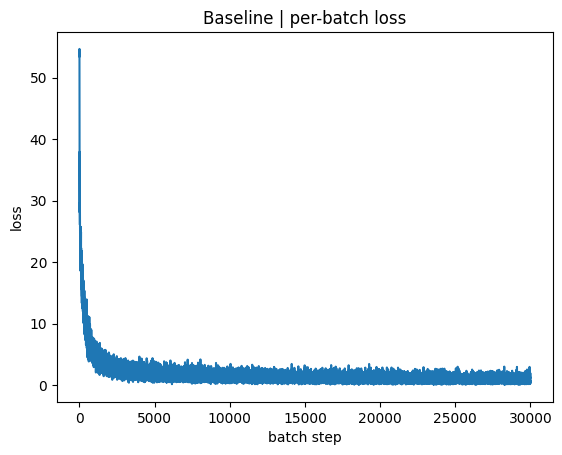

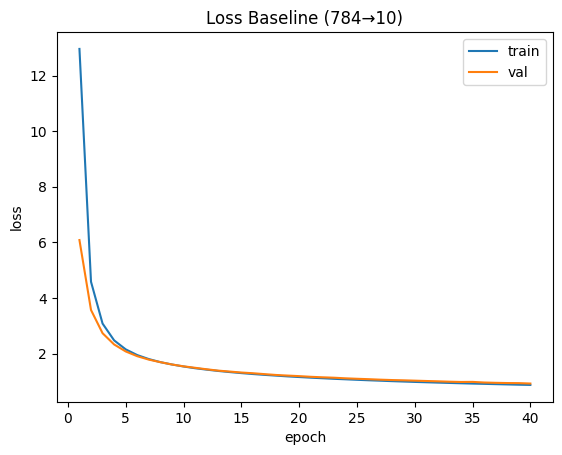

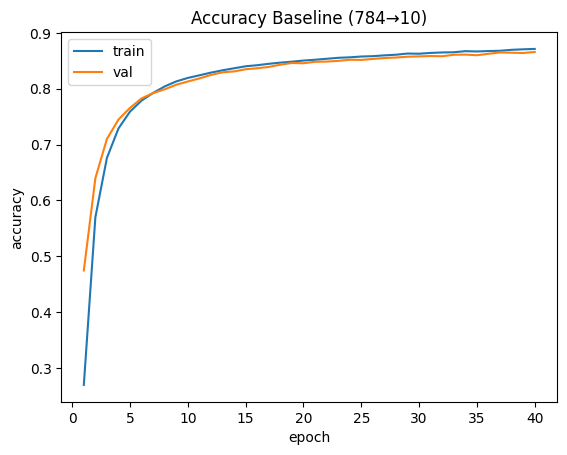

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Baseline: Linear(784 -> 10)
net = build_mnist_net("baseline", device=device)

# Entrenar (manual SGD dentro de train_model)
history, batch_losses = train_model(
    net,
    trainloader=trainloader,
    valloader=valloader,
    epochs=40,
    lr=0.01,          # baseline suele ir bien con 0.1 en batch_size=64
    device=device
)

# Plots pedidos
plot_per_batch_loss(batch_losses, title="Baseline | per-batch loss")
plot_history(history, title="Baseline (784→10)")

device: cpu
Epoch 01 | train loss 26.2491 acc 0.7678 | val loss 12.5023 acc 0.8408
Epoch 02 | train loss 9.6900 acc 0.8598 | val loss 7.6600 acc 0.8770
Epoch 03 | train loss 6.8495 acc 0.8803 | val loss 6.0044 acc 0.8861
Epoch 04 | train loss 5.4009 acc 0.8898 | val loss 5.2265 acc 0.8893
Epoch 05 | train loss 4.4175 acc 0.8975 | val loss 4.8193 acc 0.8880
Epoch 06 | train loss 3.6963 acc 0.9043 | val loss 3.8979 acc 0.8999
Epoch 07 | train loss 3.2138 acc 0.9084 | val loss 3.5970 acc 0.9025
Epoch 08 | train loss 2.8013 acc 0.9125 | val loss 3.3740 acc 0.9030
Epoch 09 | train loss 2.4796 acc 0.9166 | val loss 3.0170 acc 0.9063
Epoch 10 | train loss 2.2323 acc 0.9195 | val loss 2.8678 acc 0.9104
Epoch 11 | train loss 2.0048 acc 0.9237 | val loss 2.6478 acc 0.9126
Epoch 12 | train loss 1.8564 acc 0.9257 | val loss 2.4216 acc 0.9147
Epoch 13 | train loss 1.7076 acc 0.9277 | val loss 2.5144 acc 0.9099
Epoch 14 | train loss 1.5717 acc 0.9299 | val loss 2.5665 acc 0.9027
Epoch 15 | train los

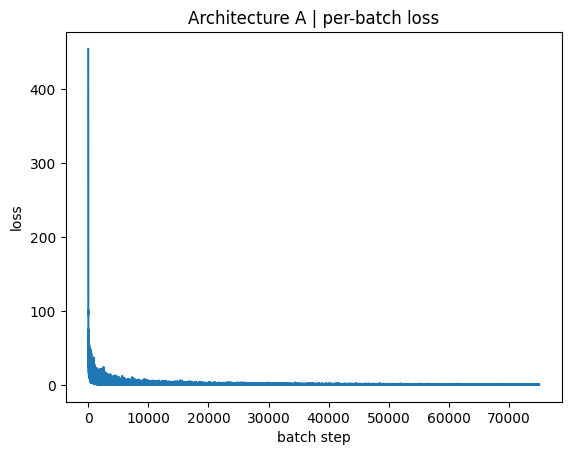

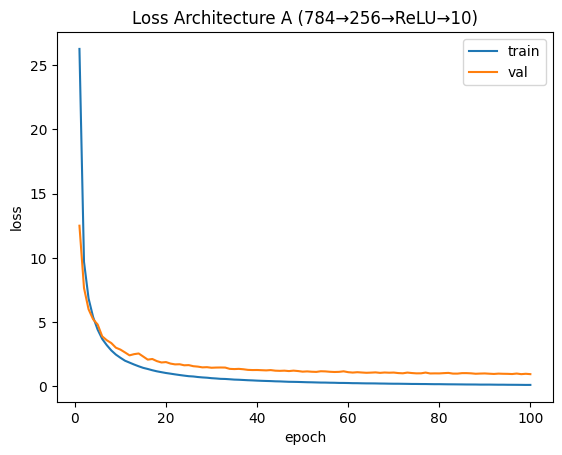

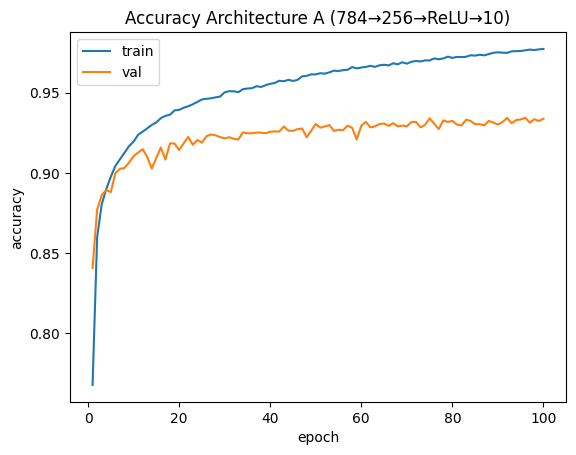

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Arquitectura A: Linear(784→256) → ReLU → Linear(256→10)
net = build_mnist_net("A", device=device)

# Entrenar (manual SGD dentro de train_model)
history, batch_losses = train_model(
    net,
    trainloader=trainloader,
    valloader=valloader,
    epochs=100,
    lr=0.01,      # suele funcionar bien para A
    device=device
)

# Plots
plot_per_batch_loss(batch_losses, title="Architecture A | per-batch loss")
plot_history(history, title="Architecture A (784→256→ReLU→10)")

device: cpu


Epoch 01 | train loss 8.5749 acc 0.3083 | val loss 2.3770 acc 0.5852
Epoch 02 | train loss 3.1800 acc 0.5142 | val loss 1.3666 acc 0.6899
Epoch 03 | train loss 2.0813 acc 0.5753 | val loss 1.0228 acc 0.7213
Epoch 04 | train loss 1.5720 acc 0.6071 | val loss 0.8619 acc 0.7399
Epoch 05 | train loss 1.3094 acc 0.6283 | val loss 0.7922 acc 0.7539
Epoch 06 | train loss 1.1591 acc 0.6479 | val loss 0.7546 acc 0.7640
Epoch 07 | train loss 1.0863 acc 0.6599 | val loss 0.7246 acc 0.7734
Epoch 08 | train loss 1.0355 acc 0.6720 | val loss 0.7006 acc 0.7834
Epoch 09 | train loss 0.9948 acc 0.6828 | val loss 0.6816 acc 0.7893
Epoch 10 | train loss 0.9661 acc 0.6919 | val loss 0.6606 acc 0.7988
Epoch 11 | train loss 0.9359 acc 0.7007 | val loss 0.6434 acc 0.8029
Epoch 12 | train loss 0.9163 acc 0.7067 | val loss 0.6306 acc 0.8106
Epoch 13 | train loss 0.8926 acc 0.7156 | val loss 0.6169 acc 0.8134
Epoch 14 | train loss 0.8816 acc 0.7185 | val loss 0.6021 acc 0.8186
Epoch 15 | train loss 0.8655 acc 0

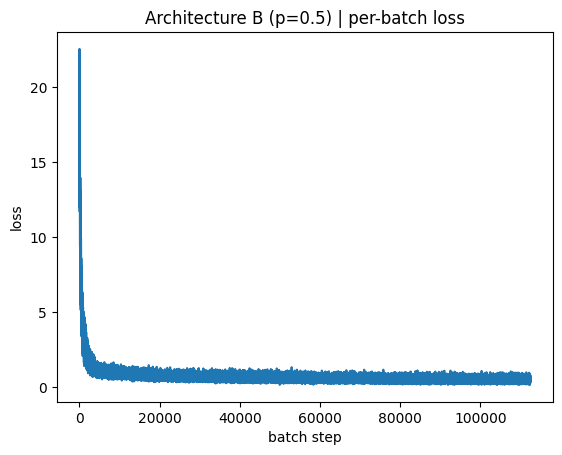

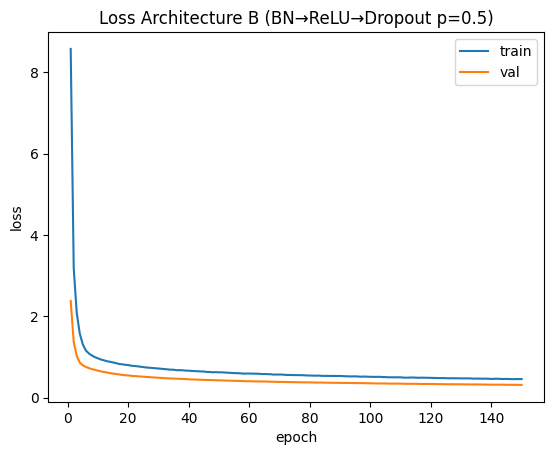

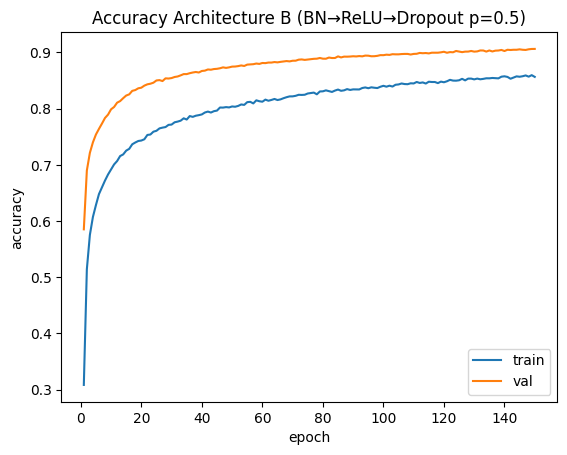

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Arquitectura B: Linear(784→256) → BatchNorm1D → ReLU → Dropout(p=0.5) → Linear(256→10)
net = build_mnist_net("B", device=device, p_drop=0.3)

history, batch_losses = train_model(
    net,
    trainloader=trainloader,
    valloader=valloader,
    epochs=150,
    lr=0.008,     # buen punto de partida con BN+Dropout
    device=device
)

plot_per_batch_loss(batch_losses, title="Architecture B (p=0.3) | per-batch loss")
plot_history(history, title="Architecture B (BN→ReLU→Dropout p=0.3)")

Adding Dropout and Batch Normalization improved the stability of training, producing smoother and less noisy curves. However, this introduced a new issue. Although the achieved loss was lower, the accuracy was also lower. This means that, even though the optimization of the loss function improved, the model makes more prediction errors, at least assuming that the validation results adequately reflect the model’s generalization ability.

In conclusion, these techniques are effective tools for stabilizing training and helping the model reach better values of the loss function, but by themselves they are not sufficient to obtain an objectively better model in this case. On the other hand, there is no clear evidence of overfitting in the accuracy and loss curves, which suggests that a deeper network might potentially achieve better results.

Note: The training accuracy curve remains below the validation curve because, during training, Dropout randomly deactivates neurons, effectively using incomplete versions of the network at each iteration. As a result, performance appears worse during training. When evaluating on the validation set, all neurons are active, so the reported accuracy better reflects the model’s true representational capacity.

device: cpu
Epoch 01 | train loss 8.8314 acc 0.2774 | val loss 1.6768 acc 0.6380
Epoch 02 | train loss 3.5829 acc 0.4556 | val loss 1.0146 acc 0.7147
Epoch 03 | train loss 2.2990 acc 0.5166 | val loss 0.8336 acc 0.7375
Epoch 04 | train loss 1.7142 acc 0.5490 | val loss 0.7911 acc 0.7446
Epoch 05 | train loss 1.4680 acc 0.5636 | val loss 0.7966 acc 0.7535
Epoch 06 | train loss 1.3315 acc 0.5788 | val loss 0.8056 acc 0.7580
Epoch 07 | train loss 1.2610 acc 0.5931 | val loss 0.7952 acc 0.7699
Epoch 08 | train loss 1.2137 acc 0.6062 | val loss 0.7642 acc 0.7833
Epoch 09 | train loss 1.1699 acc 0.6172 | val loss 0.7492 acc 0.7857
Epoch 10 | train loss 1.1381 acc 0.6288 | val loss 0.7142 acc 0.7949
Epoch 11 | train loss 1.1056 acc 0.6356 | val loss 0.6949 acc 0.8000
Epoch 12 | train loss 1.0751 acc 0.6474 | val loss 0.6723 acc 0.8063
Epoch 13 | train loss 1.0544 acc 0.6537 | val loss 0.6573 acc 0.8098
Epoch 14 | train loss 1.0243 acc 0.6627 | val loss 0.6348 acc 0.8180
Epoch 15 | train loss 

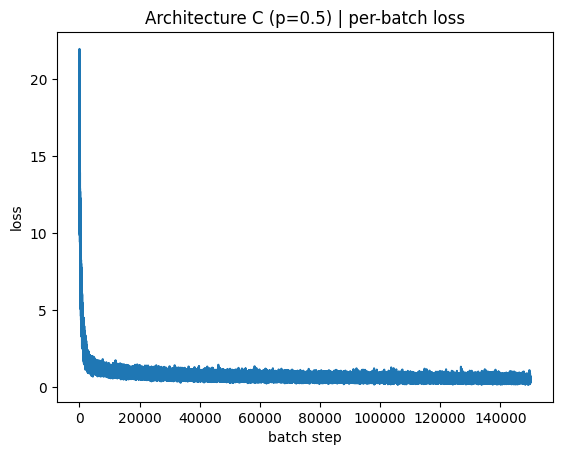

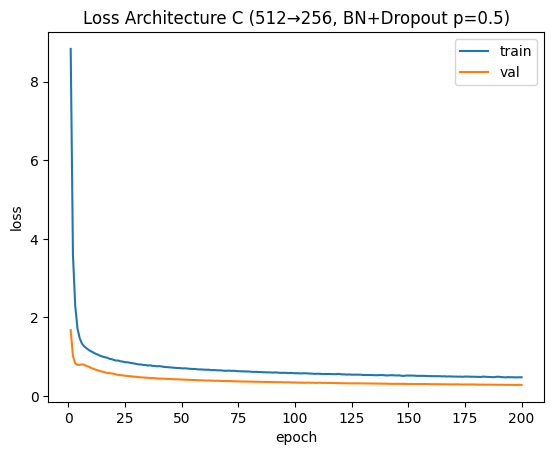

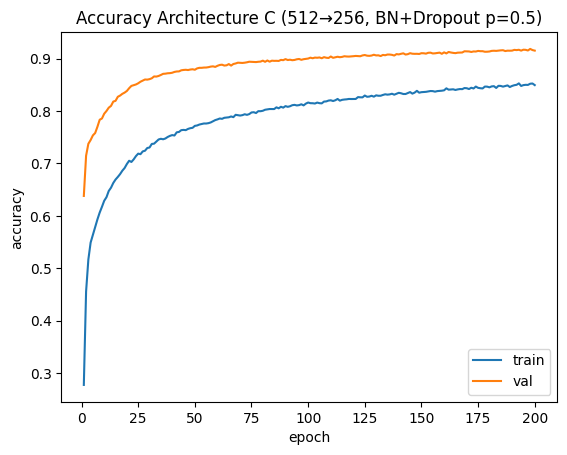

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Arquitectura C: 784→512→BN→ReLU→Dropout(p=0.5)→256→BN→ReLU→Dropout(p=0.5)→10
net = build_mnist_net("C", device=device, p_drop=0.3)

history, batch_losses = train_model(
    net,
    trainloader=trainloader,
    valloader=valloader,
    epochs=200,
    lr=0.008,     # en redes más profundas suele ser más estable un lr menor
    device=device
)

plot_per_batch_loss(batch_losses, title="Architecture C (p=0.5) | per-batch loss")
plot_history(history, title="Architecture C (512→256, BN+Dropout p=0.3)")

Although the accuracy did not surpass that of the simpler architectures, there is still no clear evidence of overfitting or similar issues. Moreover, the model once again achieved a lower loss than the previous models. It is important to remember that, since this is a deeper network, suboptimal results are not unexpected, as the parameter optimization problem becomes significantly more complex.

With this in mind, and assuming that the deeper network has greater representational potential than the previous ones, refining certain aspects, such as replacing ReLU with LeakyReLU to prevent neuron death (which can hinder training, especially in the presence of Dropout), and, more importantly, adopting a more robust optimization strategy, should lead to improved performance.

For optimization, regularization will be used to prevent instability and overfitting, momentum to accelerate convergence, and a learning rate schedule to periodically reduce the step size and avoid issues such as overshooting. Thanks to the schedule, we can begin with a higher learning rate, which helps optimize the weights more quickly during the initial training iterations.

Epoch 01 | lr 0.020000 | train loss 0.2850 acc 0.9176 | val loss 0.1287 acc 0.9600
Epoch 02 | lr 0.020000 | train loss 0.1394 acc 0.9573 | val loss 0.0988 acc 0.9688
Epoch 03 | lr 0.020000 | train loss 0.1127 acc 0.9649 | val loss 0.0795 acc 0.9759
Epoch 04 | lr 0.020000 | train loss 0.0938 acc 0.9705 | val loss 0.0699 acc 0.9765
Epoch 05 | lr 0.020000 | train loss 0.0855 acc 0.9727 | val loss 0.0685 acc 0.9781
Epoch 06 | lr 0.020000 | train loss 0.0753 acc 0.9764 | val loss 0.0650 acc 0.9791
Epoch 07 | lr 0.020000 | train loss 0.0658 acc 0.9794 | val loss 0.0665 acc 0.9782
Epoch 08 | lr 0.020000 | train loss 0.0616 acc 0.9800 | val loss 0.0652 acc 0.9796
Epoch 09 | lr 0.020000 | train loss 0.0582 acc 0.9818 | val loss 0.0672 acc 0.9790
Epoch 10 | lr 0.020000 | train loss 0.0539 acc 0.9830 | val loss 0.0641 acc 0.9801
Epoch 11 | lr 0.020000 | train loss 0.0519 acc 0.9825 | val loss 0.0599 acc 0.9819
Epoch 12 | lr 0.020000 | train loss 0.0464 acc 0.9844 | val loss 0.0616 acc 0.9808
Epoc

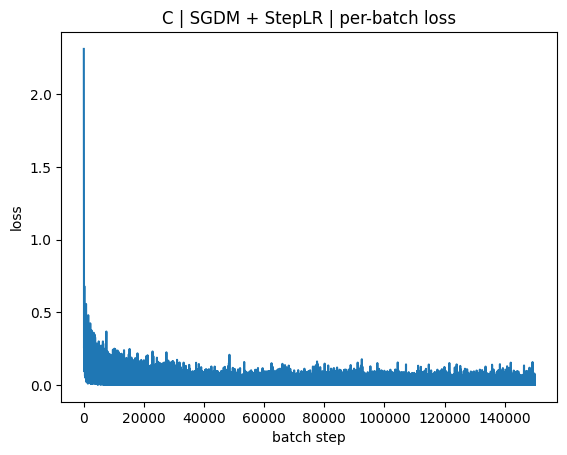

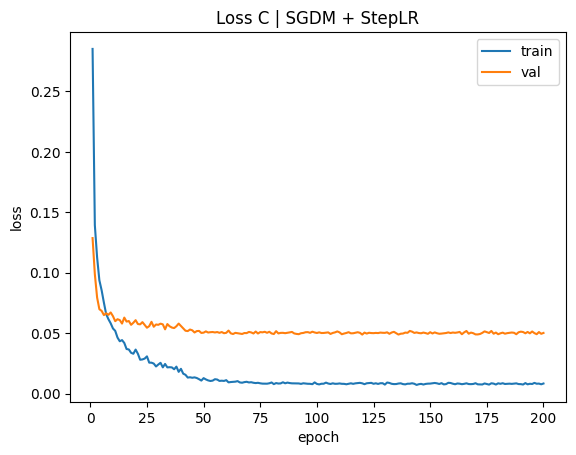

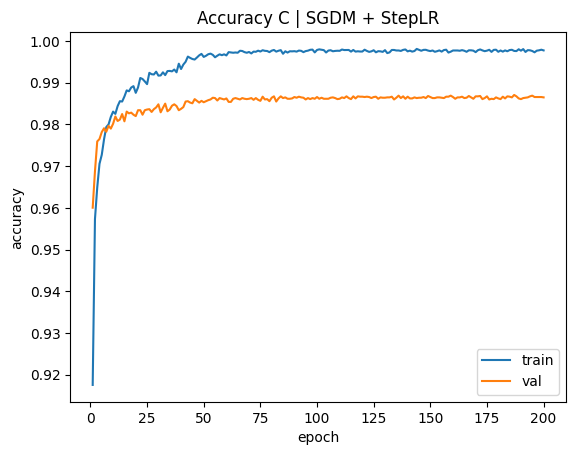

In [27]:
from minitorch_felipe import build_mnist_net, train_model_opt, SGDMomentum, step_lr, plot_per_batch_loss, plot_history

device = "cuda" if torch.cuda.is_available() else "cpu"
net = build_mnist_net("C", device=device, p_drop=0.3, activation="leaky")  # o "relu"

opt = SGDMomentum(lr=0.3, momentum=0.7, weight_decay=1e-4)

history, batch_losses = train_model_opt(
    net, trainloader, valloader,
    epochs=200, lr=0.02, device=device,
    opt=opt,
    lr_schedule=lambda ep, base_lr: step_lr(ep, base_lr, step_size=40, gamma=0.1)
)

plot_per_batch_loss(batch_losses, "C | SGDM + StepLR | per-batch loss")
plot_history(history, "C | SGDM + StepLR")

The hypothesis proved to be correct. Although the model still makes minor errors, the accuracy increased to nearly 99%, and the loss is less than one quarter of that achieved by the previous model. For now, the experimentation will stop at this point; however, there is still room to further tune hyperparameters, explore alternative optimization algorithms, and refine the network architecture to potentially achieve even better results.

These results provide additional evidence that deeper networks, when carefully designed and trained with appropriate techniques to prevent overfitting, can achieve excellent performance on relatively simple image classification tasks such as the ones considered here. As discussed in class, more complex image datasets often require additional techniques, such as convolutional neural networks (CNNs), to properly capture spatial structure and achieve strong categorization performance.